# 🌿 Estudio de Caso: Calidad del Aire y Salud Respiratoria
## Notebook del Estudiante — Completa los bloques marcados con `# TODO`

**Instrucciones generales:**
- Lee la **guía en Word** antes de ejecutar cualquier celda.
- Cada bloque `# TODO` indica exactamente qué debes completar.
- No borres las celdas de contexto ni los comentarios explicativos.
- Al finalizar, todas las celdas deben ejecutarse **sin errores** de arriba a abajo.

---
**Nombre(s):**  Oscar Javier Orellana Pinos

**Fecha:**  17/05/2026

## ⚙️ Configuración inicial
Ejecuta esta celda primero. Carga las librerías y genera el dataset del caso.

In [1]:
# ─── Librerías ────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import (shapiro, kstest, norm, ttest_1samp,
                          wilcoxon, chi2_contingency, fisher_exact,
                          pearsonr, spearmanr, probplot, binomtest)
from statsmodels.stats.proportion import proportion_confint, proportions_ztest

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titlesize': 13})
sns.set_palette('muted')
print('✅ Librerías OK')

✅ Librerías OK


In [2]:
# ─── Generación del dataset (NO modificar) ────────────────────────────────────
np.random.seed(42)
N = 240
zona = np.repeat(['A','B','C'], 80)
pm25_base = {'A': 12, 'B': 28, 'C': 58}
pm25  = np.array([np.random.lognormal(np.log(pm25_base[z]), 0.4) for z in zona])
fev1  = 95 - 0.28*pm25 + np.random.normal(0, 10, N)
fev1  = np.clip(fev1, 38, 105)
fuma  = (np.random.rand(N) < 0.26).astype(int)
sint  = (fev1 < 75) | (fuma == 1) | (np.random.rand(N) < 0.15)

df = pd.DataFrame({
    'ID'       : range(1, N+1),
    'ZONA'     : zona,
    'SEXO'     : np.where(np.random.rand(N) < 0.508, 'M', 'H'),
    'EDAD'     : np.random.randint(18, 76, N),
    'IMC'      : np.round(np.random.lognormal(np.log(26.8), 0.18, N), 1),
    'PM25'     : np.round(pm25, 1),
    'FEV1_PCT' : np.round(fev1, 1),
    'SINT_RESP': np.where(sint, 'SI', 'NO'),
    'FUMA'     : np.where(fuma, 'SI', 'NO'),
    'EJERCICIO': np.random.choice([1,2,3,4], N, p=[0.28, 0.33, 0.25, 0.14]),
    'EDU_NIVEL': np.random.choice([1,2,3,4], N, p=[0.175, 0.371, 0.35, 0.104]),
    'AÑOS_ZONA': np.round(np.random.lognormal(np.log(10), 0.7, N), 1),
})

print(f'Dataset listo: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head(8)

Dataset listo: 240 filas × 12 columnas


,ID,ZONA,SEXO,EDAD,IMC,PM25,FEV1_PCT,SINT_RESP,FUMA,EJERCICIO,EDU_NIVEL,AÑOS_ZONA
0,1,A,H,53,21.3,14.6,83.0,SI,SI,3,1,43.7
1,2,A,H,19,19.9,11.4,90.7,NO,NO,3,2,4.6
2,3,A,M,32,22.9,15.5,95.7,NO,NO,4,2,23.5
3,4,A,H,51,35.4,22.1,97.5,SI,SI,3,3,34.0
4,5,A,M,53,20.3,10.9,79.9,SI,NO,3,4,4.9
5,6,A,M,23,25.4,10.9,88.6,NO,NO,1,2,17.3
6,7,A,H,56,21.2,22.6,83.9,SI,SI,2,3,5.1
7,8,A,H,59,24.1,16.3,83.9,NO,NO,1,2,10.2


---
## 📋 Exploración inicial del dataset
Antes de cualquier análisis, familiarízate con los datos.

In [3]:
# ─── Información general ──────────────────────────────────────────────────────
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         240 non-null    int64  
 1   ZONA       240 non-null    str    
 2   SEXO       240 non-null    str    
 3   EDAD       240 non-null    int32  
 4   IMC        240 non-null    float64
 5   PM25       240 non-null    float64
 6   FEV1_PCT   240 non-null    float64
 7   SINT_RESP  240 non-null    str    
 8   FUMA       240 non-null    str    
 9   EJERCICIO  240 non-null    int64  
 10  EDU_NIVEL  240 non-null    int64  
 11  AÑOS_ZONA  240 non-null    float64
dtypes: float64(4), int32(1), int64(3), str(4)
memory usage: 21.7 KB


In [4]:
# ─── Verificación de valores faltantes ───────────────────────────────────────
# TODO: Muestra el número de valores nulos por columna.
#       Si hay nulos, comenta cómo los manejarías.

### TU CÓDIGO AQUÍ ###

df.isnull().sum()


ID           0
ZONA         0
SEXO         0
EDAD         0
IMC          0
PM25         0
FEV1_PCT     0
SINT_RESP    0
FUMA         0
EJERCICIO    0
EDU_NIVEL    0
AÑOS_ZONA    0
dtype: int64

In [5]:
# ─── Resumen descriptivo general ─────────────────────────────────────────────
# TODO: Genera el describe() para las variables numéricas.
#       Redondea a 2 decimales para mayor legibilidad.

### TU CÓDIGO AQUÍ ###
df.describe().round(2)

,ID,EDAD,IMC,PM25,FEV1_PCT,EJERCICIO,EDU_NIVEL,AÑOS_ZONA
count,240.00,240.00,240.00,240.00,240.00,240.00,240.00,240.00
mean,120.50,46.17,26.78,36.36,85.06,2.25,2.40,12.94
std,69.43,17.25,4.90,31.25,12.61,1.00,0.87,10.92
min,1.00,18.00,15.90,4.20,38.00,1.00,1.00,1.80
25%,60.75,31.00,23.30,14.42,77.45,1.00,2.00,6.10
50%,120.50,47.00,26.40,27.90,87.10,2.00,2.00,9.30
75%,180.25,61.00,29.52,49.48,94.00,3.00,3.00,16.30
max,240.00,75.00,41.80,270.80,105.00,4.00,4.00,67.60


---
## 🫁 TAREA A — Variable numérica: `FEV1_PCT` (función pulmonar)

> **Valor de referencia histórico:** la función pulmonar media de la población urbana ecuatoriana es **82%**.
> Tu objetivo es describir la distribución actual y evaluar si está por debajo de ese referente.

### A.1 — Estadísticos descriptivos (P1)

In [6]:
fev = df['FEV1_PCT']

# TODO: Calcula los siguientes estadísticos y almacénalos en variables:
#   media, mediana, desv_std, varianza, q1, q3, iqr, asimetria, curtosis, n
#   Luego imprímelos en una tabla formateada.

### TU CÓDIGO AQUÍ ###

media = fev.mean()
mediana = fev.median()
desv_std = fev.std()
varianza = fev.var()
q1 = fev.quantile(0.25)
q3 = fev.quantile(0.75)
iqr = q3 - q1
asimetria = fev.skew()
curtosis = fev.kurtosis()
n = fev.count()

# Una vez calculados, completa esta tabla de resumen:
# (No modifiques esta celda hasta haber calculado las variables de arriba)
print(f"""
=== Estadísticos descriptivos — FEV1_PCT ===
  n              : {n}
  Media          : {media:.2f}
  Mediana        : {mediana:.2f}
  Desv. estándar : {desv_std:.4f}
  Varianza       : {varianza:.4f}
  Q1 (25%)       : {q1:.2f}
  Q3 (75%)       : {q3:.2f}
  IQR            : {iqr:.2f}
  Asimetría      : {asimetria:.4f}
  Curtosis       : {curtosis:.4f}
""")


=== Estadísticos descriptivos — FEV1_PCT ===
  n              : 240
  Media          : 85.06
  Mediana        : 87.10
  Desv. estándar : 12.6077
  Varianza       : 158.9534
  Q1 (25%)       : 77.45
  Q3 (75%)       : 94.00
  IQR            : 16.55
  Asimetría      : -0.6223
  Curtosis       : 0.3698



### A.2 — Gráficos descriptivos (P1)

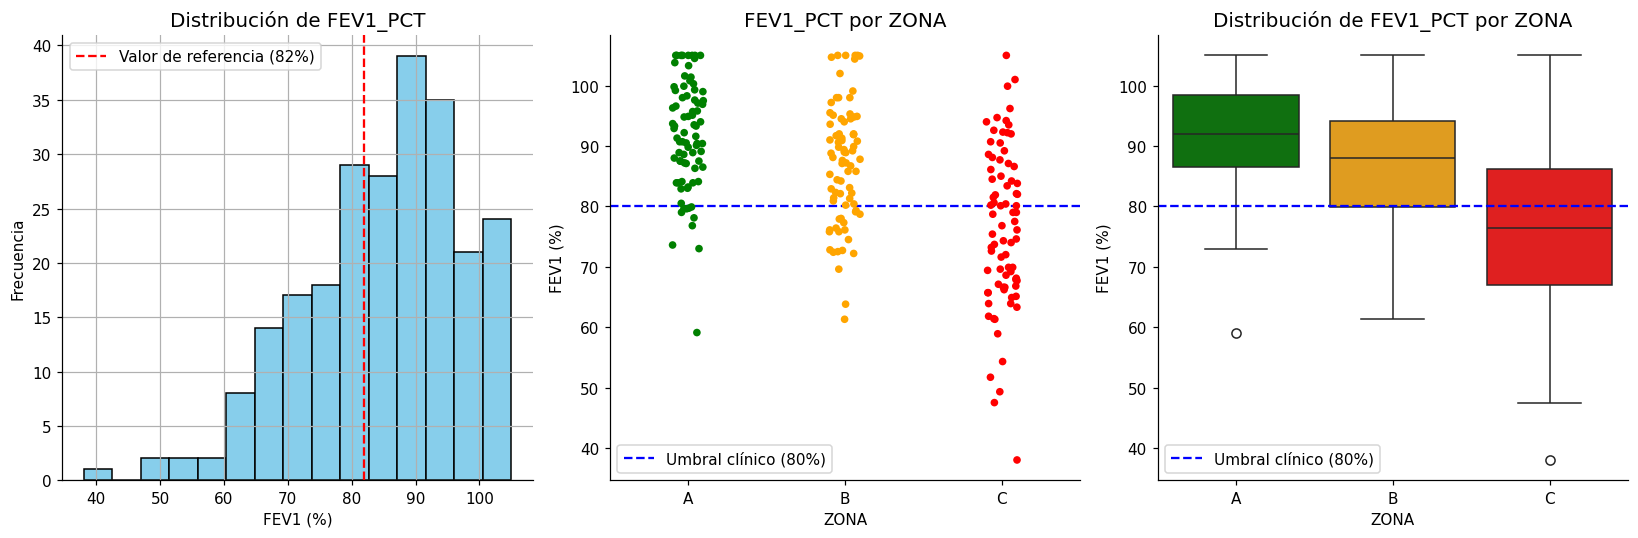

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# TODO (a): Histograma de FEV1_PCT en axes[0]
#   - Usa bins=15
#   - Añade una línea vertical en el valor de referencia (82%) con color rojo y etiqueta
#   - Añade título, etiquetas de ejes

### TU CÓDIGO AQUÍ ###

fev.hist(bins=15, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].axvline(82, color='red', linestyle='--', label='Valor de referencia (82%)')
axes[0].set_title('Distribución de FEV1_PCT')
axes[0].set_xlabel('FEV1 (%)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()


# TODO (b): Diagrama de puntos (stripplot o dotplot) en axes[1]
#   - Colorea los puntos por ZONA (A=verde, B=naranja, C=rojo)
#   - Añade línea horizontal en 80% (umbral clínico de normalidad)

### TU CÓDIGO AQUÍ ###

sns.stripplot(x='ZONA', y='FEV1_PCT', data=df, ax=axes[1],
              palette={'A':'green', 'B':'orange', 'C':'red'})
axes[1].axhline(80, color='blue', linestyle='--', label='Umbral clínico (80%)')
axes[1].set_title('FEV1_PCT por ZONA')
axes[1].set_xlabel('ZONA')
axes[1].set_ylabel('FEV1 (%)')
axes[1].legend()

# TODO (c): Diagrama de cajas por ZONA en axes[2]
#   - Muestra los tres grupos (A, B, C) en el mismo gráfico
#   - Añade una línea horizontal en 80% (umbral clínico)
#   - Añade título y etiquetas

### TU CÓDIGO AQUÍ ###

sns.boxplot(x='ZONA', y='FEV1_PCT', data=df, ax=axes[2],
            palette={'A':'green', 'B':'orange', 'C':'red'})
axes[2].axhline(80, color='blue', linestyle='--', label='Umbral clínico (80%)')
axes[2].set_title('Distribución de FEV1_PCT por ZONA')
axes[2].set_xlabel('ZONA')
axes[2].set_ylabel('FEV1 (%)')
axes[2].legend()

plt.tight_layout()
plt.show()

### A.3 — Diagnóstico de atípicos: Test de Grubbs (P2)

In [8]:
# ─── Límites por IQR (método de Tukey) ───────────────────────────────────────
# TODO: Calcula los límites inferior y superior de atípicos usando la regla 1.5×IQR.
#       Filtra e imprime los valores que caen fuera de esos límites.

### TU CÓDIGO AQUÍ ###

lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr
outliers_iqr = fev[(fev < lim_inf) | (fev > lim_sup)]
print(f"Valores atípicos según IQR (lim_inf={lim_inf:.2f}, lim_sup={lim_sup:.2f}):")
print(outliers_iqr.values)


# ─── Test de Grubbs ───────────────────────────────────────────────────────────
def grubbs_test(data, alpha=0.05):
    """Test de Grubbs para detectar un único outlier (bilateral)."""
    n     = len(data)
    mean_ = np.mean(data)
    std_  = np.std(data, ddof=1)
    G     = np.max(np.abs(data - mean_)) / std_
    t_c   = stats.t.ppf(1 - alpha / (2 * n), df=n - 2)
    G_c   = ((n - 1) / np.sqrt(n)) * np.sqrt(t_c**2 / (n - 2 + t_c**2))
    idx   = np.argmax(np.abs(data - mean_))
    return {'G': G, 'G_critico': G_c, 'valor_sospechoso': data[idx],
            'outlier': G > G_c}

# TODO: Aplica la función grubbs_test() sobre fev.values e imprime los resultados.
#       Concluye: ¿hay outlier? ¿Qué medida de tendencia central reportarías?

### TU CÓDIGO AQUÍ ###
print(grubbs_test(fev.values))

Valores atípicos según IQR (lim_inf=52.63, lim_sup=118.82):
[47.5 51.7 49.3 38. ]
{'G': np.float64(3.7326481122043176), 'G_critico': np.float64(3.6594939273309297), 'valor_sospechoso': np.float64(38.0), 'outlier': np.True_}


**📝 Respuesta P2 — ¿Promedio o mediana? Justifica:**

> *(Escribe aquí tu respuesta — máx. 5 líneas)*

Usaria la mediana, ya que la distribución muestra una gran cantidad de personas con valores de 90 o más lo que al promediar no demostraría un valor realmente confiable, además claramente tenemos valores que están por muy debajo de lo que se esperaría en su zona lo cual el promedio pudiera ser una medida engañosa si queremos interpretar mejor el efecto en la cálidad de la respiración. No deberíamos eliminar estos outliers sino ver si sus condiciones adicionales pudieran ser el causante del porcentaje FEV recibido, revisar si no sufría de alguna otra condicion, y comparar con un sujeto que tenía condiciones iniciales pudieramos identificar si el dato fue mal recogido.

### A.4 — Diagnóstico de normalidad (P3)

In [9]:
# ─── Tests formales de normalidad ────────────────────────────────────────────
# TODO: Ejecuta Shapiro-Wilk y Kolmogorov-Smirnov sobre fev.
#       Imprime: estadístico, p-valor y conclusión (normal / no normal) para cada test.

### TU CÓDIGO AQUÍ ###

shapiro_stat, shapiro_p = shapiro(fev)
kstest_stat, kstest_p = kstest(fev, 'norm', args=(fev.mean(), fev.std(ddof=1)))
print(f"Shapiro-Wilk: estadístico={shapiro_stat:.4f}, p-valor={shapiro_p:.4f}, "
      f"conclusión={'Normal' if shapiro_p > 0.05 else 'No normal'}")
print(f"Kolmogorov-Smirnov: estadístico={kstest_stat:.4f}, p-valor={kstest_p:.4f}, "
      f"conclusión={'Normal' if kstest_p > 0.05 else 'No normal'}")


Shapiro-Wilk: estadístico=0.9688, p-valor=0.0000, conclusión=No normal
Kolmogorov-Smirnov: estadístico=0.0726, p-valor=0.1516, conclusión=Normal


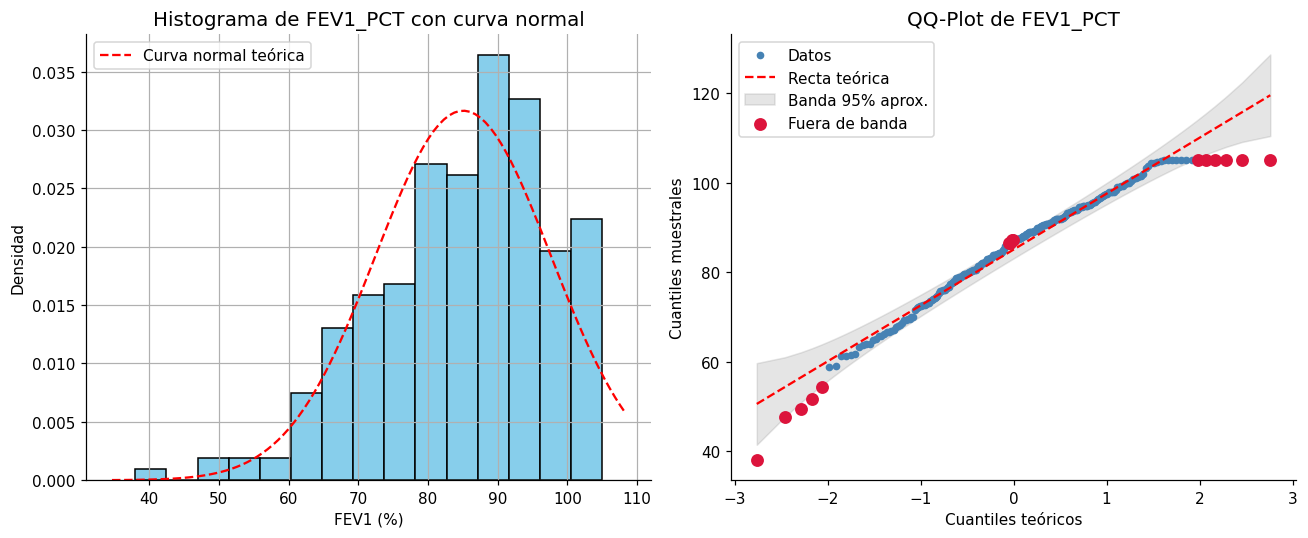

In [10]:
# ─── QQ-Plot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# TODO (a): Histograma con curva normal teórica superpuesta en axes[0]

### TU CÓDIGO AQUÍ ###

fev.hist(bins=15, ax=axes[0], color='skyblue', edgecolor='black', density=True)
xmin, xmax = axes[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, fev.mean(), fev.std())
axes[0].plot(x, p, 'r--', label='Curva normal teórica')
axes[0].set_title('Histograma de FEV1_PCT con curva normal')
axes[0].set_xlabel('FEV1 (%)')
axes[0].set_ylabel('Densidad')
axes[0].legend()

# TODO (b): QQ-Plot en axes[1]
#   Usa scipy.stats.probplot. Añade la banda de confianza aproximada.
#   Marca con anotaciones cualquier punto fuera de la banda.

### TU CÓDIGO AQUÍ ###

fev_ordenado = fev.dropna().sort_values()
n = len(fev_ordenado)
(osm, osr), (slope, intercept, _) = probplot(fev_ordenado, dist='norm', fit=True)
osm = np.asarray(osm)
osr = np.asarray(osr)
p = (np.arange(1, n + 1) - 0.375) / (n + 0.25)
se_q = np.sqrt(p * (1 - p) / (n * norm.pdf(osm) ** 2))
lower = intercept + slope * (osm - 1.96 * se_q)
upper = intercept + slope * (osm + 1.96 * se_q)
axes[1].plot(osm, osr, 'o', color='steelblue', markersize=4, label='Datos')
axes[1].plot(osm, intercept + slope * osm, 'r--', label='Recta teórica')
axes[1].fill_between(osm, lower, upper, color='gray', alpha=0.2, label='Banda 95% aprox.')
fuera_banda = (osr < lower) | (osr > upper)
if np.any(fuera_banda):
    axes[1].scatter(osm[fuera_banda], osr[fuera_banda], color='crimson', s=55, zorder=3, label='Fuera de banda')


axes[1].set_title('QQ-Plot de FEV1_PCT')
axes[1].set_xlabel('Cuantiles teóricos')
axes[1].set_ylabel('Cuantiles muestrales')
axes[1].legend()

plt.tight_layout()
plt.show()




**📝 Respuesta P3 — Decisión sobre normalidad y prueba a usar:**

| Aspecto | Tu respuesta |
|---|---|
| Shapiro-Wilk p-valor | 0 |
| K-S p-valor | 0.1516|
| ¿Los tests coinciden? | No |
| Conclusión sobre normalidad | Pueden haber datos que afecten la normalidad de la distribución |
| **Prueba de hipótesis a usar** | Shapiro-Wilk |
| Justificación de la elección | En general Shapiro-Wilk es mas sensible y según la literatura se recomienda para datasets mas pequeños que en nuestro caso aplica n = 250 |

### A.5 — Contraste de hipótesis (P4)

In [ ]:
MU0 = 82   # Valor de referencia histórico (función pulmonar media)

# ─── Intervalo de confianza al 95% ───────────────────────────────────────────
# TODO: Calcula el IC al 95% para la media de FEV1_PCT usando t de Student.
#       Imprime: [límite inferior, límite superior]
#       ¿El valor 82 cae dentro del IC?

### TU CÓDIGO AQUÍ ###

se = desv_std / np.sqrt(n)
t_critico = stats.t.ppf(0.95, df=n-1)
ic_inf = media - t_critico * se
ic_sup = media + t_critico * se
print(f"Intervalo de confianza al 95% para la media de FEV1_PCT: [{ic_inf:.2f}, {ic_sup:.2f}]")
print(f"¿El valor {MU0} cae dentro del IC? {'Sí' if ic_inf <= MU0 <= ic_sup else 'No'}")    



# ─── t-test paramétrico (ilustrativo) ────────────────────────────────────────
# TODO: Ejecuta ttest_1samp con alternative='less' (H1: μ < 82).
#       Imprime estadístico t, p-valor y conclusión.

### TU CÓDIGO AQUÍ ###

t_stat, p_val = ttest_1samp(fev, popmean=MU0, alternative='less')
print(f"t-test: estadístico={t_stat:.4f}, p-valor={p_val:.4f}, "
      f"conclusión={'Rechazar H0 (μ < 82)' if p_val < 0.05 else 'No rechazar H0 (μ >= 82)'}") 


# ─── Test de Wilcoxon (no paramétrico — el correcto según P3) ─────────────────
# TODO: Ejecuta el test de Wilcoxon de rangos con signo.
#       H0: mediana = 82   H1: mediana < 82
#       Imprime estadístico V, p-valor y conclusión.

### TU CÓDIGO AQUÍ ###

V_stat, p_val = wilcoxon(fev - MU0, alternative='less')
print(f"Wilcoxon: estadístico={V_stat:.4f}, p-valor={p_val:.4f}, "
      f"conclusión={'Rechazar H0 (mediana < 82)' if p_val < 0.05 else 'No rechazar H0 (mediana >= 82)'}")

#USAMOS WILCOXON YA QUE NOS DECIDIMOS QUE LA DISTRIBUCIÓN NO ES NORMAL Y QUEREMOS PROBAR UNA HIPÓTESIS SOBRE LA MEDIANA.      


Intervalo de confianza al 95% para la media de FEV1_PCT: [83.72, 86.40]
¿El valor 82 cae dentro del IC? No
t-test: estadístico=3.7600, p-valor=0.9999, conclusión=No rechazar H0 (μ >= 82)
Wilcoxon: estadístico=18813.0000, p-valor=1.0000, conclusión=No rechazar H0 (mediana >= 82)


**📝 Respuesta P4 — Redacta la conclusión para un boletín epidemiológico (máx. 3 oraciones, sin jerga técnica):**

> *(Escribe aquí — recuerda: tu audiencia son funcionarios de salud pública, no estadísticos)*



**📝 Respuesta P5 — Limitaciones del diseño ex post facto:**

> **¿Podemos afirmar causalidad?**
> 
> **Dos variables de confusión no controladas en este análisis univariado:**
> 1. 
> 2. 
>
> **¿Cómo cambiaría la conclusión si la muestra estuviera sesgada hacia Zona C?**

---
## 🚨 TAREA B — Variable dicotómica: `SINT_RESP` (síntomas respiratorios)

> **Línea base histórica:** prevalencia de síntomas en población urbana sin exposición industrial elevada = **35%**.

### B.1 — Frecuencias y gráficos (P6)

In [12]:
# ─── Frecuencias globales ─────────────────────────────────────────────────────
# TODO: Calcula frecuencias absolutas y relativas de SINT_RESP.
#       Guarda en variables: n_si, n_no, n_total, prop_si

### TU CÓDIGO AQUÍ ###

freq_absolutas = df['SINT_RESP'].value_counts()
n_si = freq_absolutas.get('SI', 0)
n_no = freq_absolutas.get('NO', 0)
n_total = n_si + n_no
prop_si = n_si / n_total if n_total > 0 else 0
print(f"Frecuencias absolutas de SINT_RESP:\n{freq_absolutas}")
print(f"Total: {n_total}, Proporción SI: {prop_si:.4f}")

freq_relativas = df['SINT_RESP'].value_counts(normalize=True)
print(f"Frecuencias relativas de SINT_RESP:\n{freq_relativas.round(4)}") 



# ─── Frecuencias por ZONA ─────────────────────────────────────────────────────
# TODO: Crea una tabla cruzada ZONA × SINT_RESP con porcentajes por fila.
#       Imprime la tabla.

### TU CÓDIGO AQUÍ ###

tabla_cruzada = pd.crosstab(df['ZONA'], df['SINT_RESP'], normalize='index') * 100
print("Tabla cruzada ZONA × SINT_RESP (porcentajes por fila):")
print(tabla_cruzada.round(2))


Frecuencias absolutas de SINT_RESP:
SINT_RESP
SI    128
NO    112
Name: count, dtype: int64
Total: 240, Proporción SI: 0.5333
Frecuencias relativas de SINT_RESP:
SINT_RESP
SI    0.5333
NO    0.4667
Name: proportion, dtype: float64
Tabla cruzada ZONA × SINT_RESP (porcentajes por fila):
SINT_RESP     NO     SI
ZONA                   
A          51.25  48.75
B          52.50  47.50
C          36.25  63.75


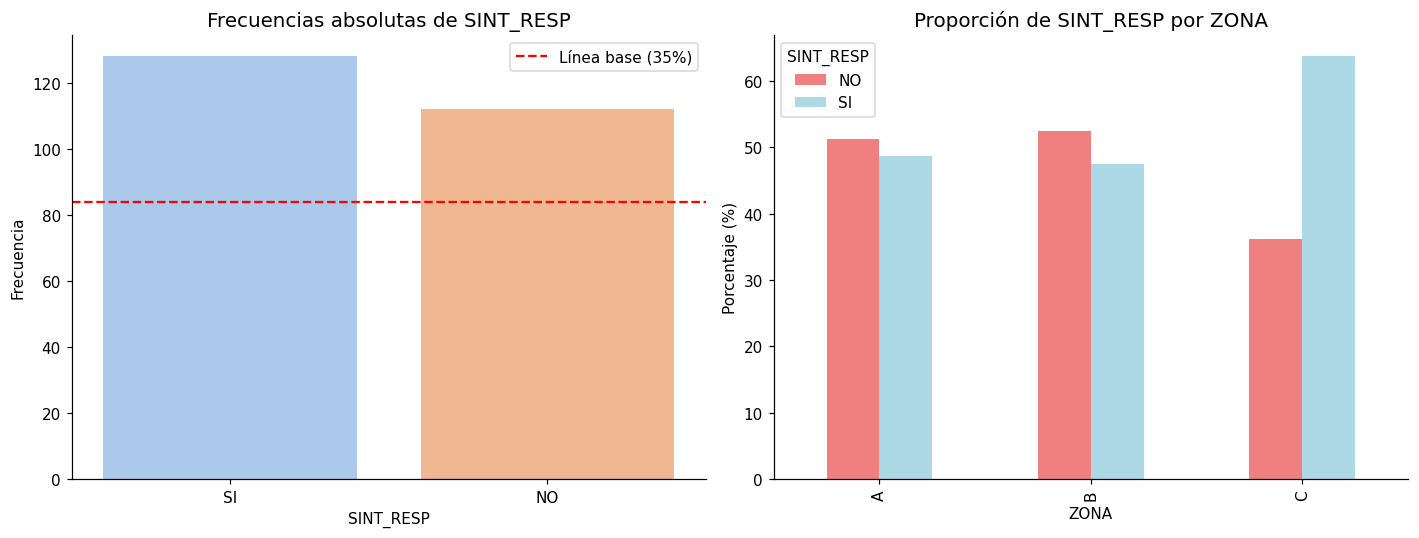

In [13]:
# ─── Gráficos (P6) ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# TODO (a): Gráfico de barras simple (global) en axes[0]
#   - Muestra frecuencias absolutas de SINT_RESP (SI / NO)
#   - Añade una línea horizontal en el nivel esperado si prevalencia = 35% (0.35 × n_total)
#   - Etiqueta la línea como 'Línea base (35%)'

### TU CÓDIGO AQUÍ ###

sns.barplot(x=freq_absolutas.index, y=freq_absolutas.values, ax=axes[0], palette='pastel')
axes[0].axhline(0.35 * n_total, color='red', linestyle='--', label='Línea base (35%)')
axes[0].set_title('Frecuencias absolutas de SINT_RESP')
axes[0].set_xlabel('SINT_RESP')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()


# TODO (b): Gráfico de barras agrupadas por ZONA en axes[1]
#   - Eje Y en porcentaje (0–100)
#   - Leyenda que distinga SI / NO
#   - Título descriptivo

### TU CÓDIGO AQUÍ ###

tabla_cruzada.plot(kind='bar', stacked=False, ax=axes[1], color=['lightcoral', 'lightblue'])
axes[1].set_title('Proporción de SINT_RESP por ZONA')
axes[1].set_xlabel('ZONA')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].legend(title='SINT_RESP', labels=['NO', 'SI'])

plt.tight_layout()
plt.show()

### B.2 — Intervalo de confianza para la proporción (P6)

In [14]:
# TODO: Calcula el IC al 95% para la proporción de SINT_RESP = SI.
#       Usa el método 'wilson' (más robusto que el normal aproximado).
#       Imprime: proporción muestral, IC inferior, IC superior.
#       Indica si el valor histórico (0.35) cae dentro del IC.

### TU CÓDIGO AQUÍ ###

ic_inf, ic_sup = proportion_confint(n_si, n_total, method='wilson')
print(f"Proporción muestral de SINT_RESP = SI: {prop_si:.4f}")
print(f"Intervalo de confianza al 95% para la proporción: [{ic_inf:.4f}, {ic_sup:.4f}]")
print(f"¿El valor histórico 0.35 cae dentro del IC? {'Sí' if ic_inf <= 0.35 <= ic_sup else 'No'}")



Proporción muestral de SINT_RESP = SI: 0.5333
Intervalo de confianza al 95% para la proporción: [0.4702, 0.5954]
¿El valor histórico 0.35 cae dentro del IC? No


### B.3 — Contraste de hipótesis para la proporción (P7)

In [15]:
P0_sint = 0.35   # Prevalencia histórica

# ─── Test Chi-cuadrado (1 proporción) ────────────────────────────────────────
# TODO: Ejecuta proportions_ztest con alternative='larger'.
#       Verifica que frec. esperadas de éxito Y fracaso sean >= 5 (condición Chi²).
#       Imprime: estadístico, p-valor, conclusión.

### TU CÓDIGO AQUÍ ###

prueba_chi2 = proportions_ztest(count=n_si, nobs=n_total, value=P0_sint, alternative='larger')
print(f"Chi² (proportions_ztest): estadístico={prueba_chi2[0]:.4f}, p-valor={prueba_chi2[1]:.4f}, "
      f"conclusión={'Rechazar H0 (proporción > 0.35)' if prueba_chi2[1] < 0.05 else 'No rechazar H0 (proporción <= 0.35)'}") 

# ─── Test binomial exacto ─────────────────────────────────────────────────────
# TODO: Ejecuta binomtest con alternative='greater'.
#       Imprime: p-valor, conclusión.
#       ¿Coincide con el Chi²? ¿Por qué podrían diferir?

### TU CÓDIGO AQUÍ ###

binom_result = binomtest(n_si, n_total, P0_sint, alternative='greater')
print(f"Binomial exacto: p-valor={binom_result.pvalue:.4f}, "
      f"conclusión={'Rechazar H0 (proporción > 0.35)' if binom_result.pvalue < 0.05 else 'No rechazar H0 (proporción <= 0.35)'}") 


Chi² (proportions_ztest): estadístico=5.6930, p-valor=0.0000, conclusión=Rechazar H0 (proporción > 0.35)
Binomial exacto: p-valor=0.0000, conclusión=Rechazar H0 (proporción > 0.35)


**📝 Respuesta P7 — ¿Chi-cuadrado o test binomial exacto? ¿Cuándo preferirías cada uno?**

> *(Escribe aquí tu respuesta)*

### B.4 — Pensamiento crítico: efecto del tabaquismo (P8)

In [16]:
# TODO: Calcula la prevalencia de SINT_RESP = SI separando FUMADORES de NO FUMADORES.
#       Muestra una tabla con: grupo, n, n_sint, prevalencia (%).
#       Comenta: ¿el tabaquismo podría explicar parte del aumento de síntomas?

### TU CÓDIGO AQUÍ ###

prevalencia_fuma = df.groupby('FUMA')['SINT_RESP'].value_counts(normalize=True).unstack().fillna(0) * 100
print("Prevalencia de SINT_RESP = SI por grupo de FUMA:")
print(prevalencia_fuma.round(2))

Prevalencia de SINT_RESP = SI por grupo de FUMA:
SINT_RESP     NO      SI
FUMA                    
NO         64.74   35.26
SI          0.00  100.00


**📝 Respuesta P8 — ¿Está el coordinador en lo correcto al atribuir todo el efecto a la contaminación?**

> *(Escribe aquí tu análisis crítico — usa los números que calculaste arriba)*

---
## 📈 TAREA C — Correlación: `PM25` vs `FEV1_PCT`

> **Hipótesis central:** a mayor PM2.5 → menor FEV1_PCT.  
> ¡Cuidado! Este análisis contiene una **trampa deliberada**. Tu trabajo incluye detectarla.

### C.1 — Diagrama de dispersión (P9)

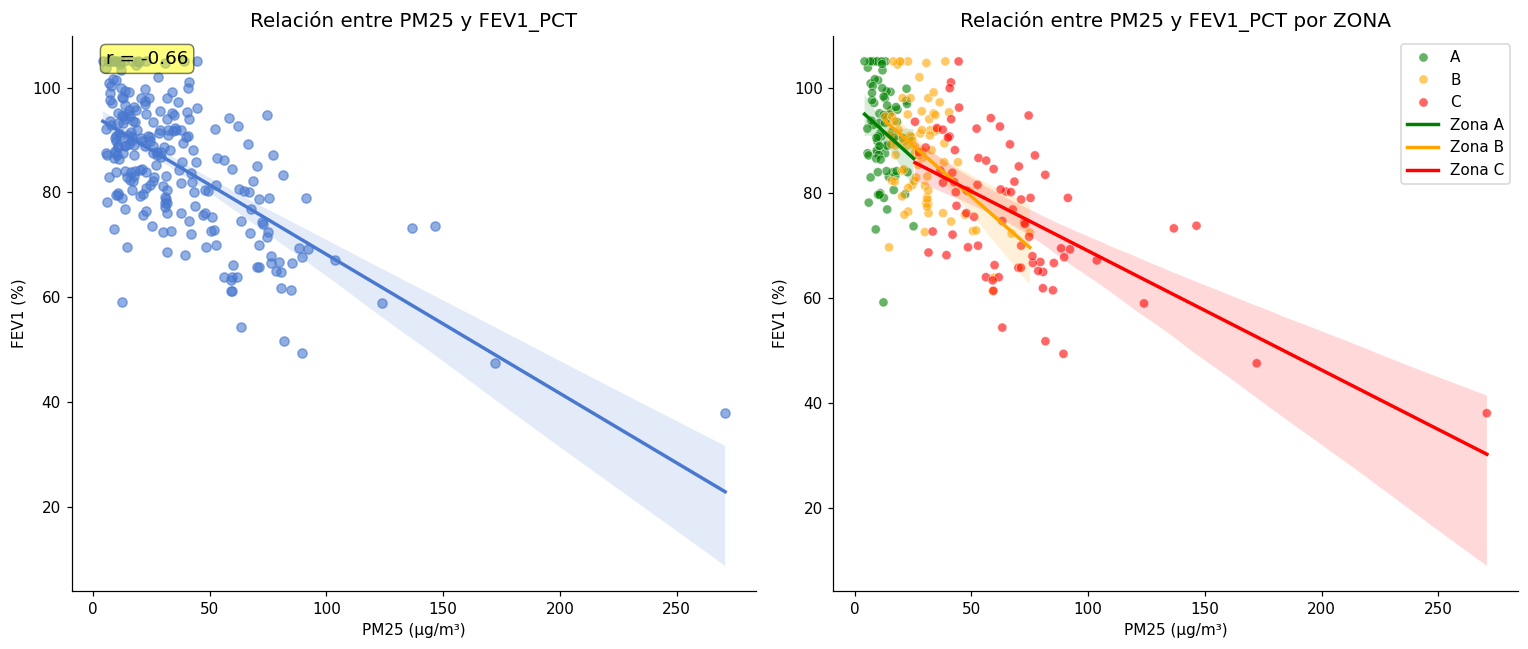


=== Observación visual ===


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# TODO (a): Scatterplot PM25 vs FEV1_PCT (muestra TOTAL) en axes[0]
#   - Incluye línea de regresión de mínimos cuadrados
#   - Incluye boxplots marginales (puedes usar sns.jointplot en una figura separada si prefieres)
#   - Añade el coeficiente r en el título o como anotación

### TU CÓDIGO AQUÍ ###

sns.regplot(x='PM25', y='FEV1_PCT', data=df, ax=axes[0], scatter_kws={'alpha':0.6})
axes[0].set_title('Relación entre PM25 y FEV1_PCT')
axes[0].set_xlabel('PM25 (µg/m³)')
axes[0].set_ylabel('FEV1 (%)')
r, p = pearsonr(df['PM25'], df['FEV1_PCT'])
axes[0].annotate(f'r = {r:.2f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12, bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.5))


# TODO (b): Scatterplot PM25 vs FEV1_PCT COLOREADO POR ZONA en axes[1]
#   - Zona A: verde, Zona B: naranja, Zona C: rojo
#   - Añade líneas de regresión separadas por zona (usa np.polyfit o seaborn lmplot)
#   - Leyenda de zonas

### TU CÓDIGO AQUÍ ###

sns.scatterplot(x='PM25', y='FEV1_PCT', hue='ZONA', data=df, ax=axes[1],
                palette={'A':'green', 'B':'orange', 'C':'red'}, alpha=0.6)
for zona, color in zip(['A', 'B', 'C'], ['green', 'orange', 'red']):
    subset = df[df['ZONA'] == zona]
    sns.regplot(x='PM25', y='FEV1_PCT', data=subset, ax=axes[1], scatter=False, color=color, label=f'Zona {zona}')
axes[1].set_title('Relación entre PM25 y FEV1_PCT por ZONA')
axes[1].set_xlabel('PM25 (µg/m³)')
axes[1].set_ylabel('FEV1 (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

# TODO (c): Describe lo que observas en el gráfico (b) comparado con (a).
#           ¿Son las tendencias dentro de cada zona iguales a la tendencia global?
print('\n=== Observación visual ===')
# Tu comentario aquí:


### C.2 — Selección de coeficiente de correlación (P10)

In [18]:
# ─── Paso 1: Normalidad de PM25 ───────────────────────────────────────────────
# TODO: Ejecuta Shapiro-Wilk sobre PM25. Imprime p-valor y conclusión.

### TU CÓDIGO AQUÍ ###

shapiro_stat, shapiro_p = shapiro(df['PM25'])
print(f"Shapiro-Wilk para PM25: estadístico={shapiro_stat:.4f}, p-valor={shapiro_p:.4f}, "
      f"conclusión={'Normal' if shapiro_p > 0.05 else 'No normal'}")

# ─── Paso 2: Normalidad de FEV1_PCT (ya calculada en Tarea A) ─────────────────
# (Escribe el resultado de la Tarea A aquí como comentario para referencia)
# FEV1_PCT normalidad: p-valor SW = ______, ¿normal? ______


# ─── Paso 3: Correlaciones ────────────────────────────────────────────────────
# TODO: Calcula Pearson y Spearman entre PM25 y FEV1_PCT.
#       Imprime r/ρ y p-valor para cada uno.
#       Comenta: ¿difieren? ¿Cuál es más apropiado y por qué?

### TU CÓDIGO AQUÍ ###


Shapiro-Wilk para PM25: estadístico=0.7763, p-valor=0.0000, conclusión=No normal


**📝 Respuesta P10 — Justifica paso a paso tu elección de coeficiente:**

| Paso | Resultado | Implicación |
|---|---|---|
| Normalidad PM25 | | |
| Normalidad FEV1_PCT | | |
| ¿Relación lineal en el gráfico? | | |
| **Coeficiente elegido** | | |
| Valor obtenido + p-valor | | |
| Interpretación | | |

### C.3 — ⚠️ TRAMPA: Paradoja de Simpson (P11 — vale puntos extra)

In [19]:
# ─── Correlación global (ya calculada arriba) ─────────────────────────────────
# r_global = ???   # Recuerda el valor de P10


# ─── Correlación DENTRO de cada zona ─────────────────────────────────────────
# TODO: Calcula la correlación (Spearman o Pearson, según P10) entre PM25 y FEV1_PCT
#       SEPARADA POR ZONA (A, B y C).
#       Imprime zona, coeficiente, p-valor para cada una.

### TU CÓDIGO AQUÍ ###


# TODO: Compara los resultados dentro-de-zona vs. la correlación global.
#       ¿Son diferentes en magnitud? ¿En signo?
print('\n=== Comparación global vs. por zona ===')
# Tu comentario aquí:



=== Comparación global vs. por zona ===


**📝 Respuesta P11 — Paradoja de Simpson (puntos extra):**

> **¿Qué es la Paradoja de Simpson?**
>
> **¿Se presenta aquí? ¿Por qué ocurre en este caso?**
>
> **¿Qué implicación metodológica tiene para el estudio?**
>
> **¿Qué correlación reportarías en el informe final: la global o la por zona?**

---
## 🔗 TAREA D — Asociación entre variables categóricas

### D.1 — EDU_NIVEL × SINT_RESP (P12)

In [20]:
# ─── Tabla de contingencia ────────────────────────────────────────────────────
# TODO: Crea la tabla de contingencia EDU_NIVEL × SINT_RESP con pd.crosstab.
#       Calcula también los porcentajes por columna.

### TU CÓDIGO AQUÍ ###


# ─── Gráfico ──────────────────────────────────────────────────────────────────
# TODO: Gráfico de barras agrupadas (proporciones por nivel educativo).
#       EDU_NIVEL en eje X (1=Primaria…4=Postgrado), SINT_RESP en colores.

### TU CÓDIGO AQUÍ ###


# ─── Chi-cuadrado de independencia ───────────────────────────────────────────
# TODO: Ejecuta chi2_contingency. Imprime: X², df, p-valor.
#       VERIFICA la condición: ¿todas las frecuencias esperadas son >= 5?
#       Si no, ¿qué alternativa usarías?

### TU CÓDIGO AQUÍ ###


### D.2 — SEXO × FUMA (P12 + P13)

In [21]:
# ─── Tabla de contingencia ────────────────────────────────────────────────────
# TODO: Crea la tabla SEXO × FUMA (2×2).
#       Imprime frecuencias observadas y porcentajes por fila.

### TU CÓDIGO AQUÍ ###


# ─── Chi² con corrección de Yates + Fisher exacto ────────────────────────────
# TODO: Ejecuta chi2_contingency(correction=True) y fisher_exact.
#       Imprime p-valores de ambos. ¿Coinciden?

### TU CÓDIGO AQUÍ ###


# ─── Odds Ratio e IC ─────────────────────────────────────────────────────────
# TODO: Extrae el Odds Ratio del resultado de fisher_exact.
#       Calcula el IC 95% del OR usando la fórmula logarítmica:
#         IC = exp(log(OR) ± 1.96 * sqrt(1/a + 1/b + 1/c + 1/d))
#       donde a,b,c,d son las celdas de la tabla 2×2.
#       Imprime: OR, IC inferior, IC superior.

### TU CÓDIGO AQUÍ ###


**📝 Respuesta P13 — Interpreta el Odds Ratio en términos clínicos:**

> **OR =** _____  
> **IC 95%:** (_____, _____)  
> **¿El IC incluye el 1?** _____  
> **Significado estadístico:** _____  
> **Significado clínico (sin jerga):** _____  
> **¿Podría FUMA ser variable de confusión en la relación ZONA → FEV1_PCT?** _____

### D.3 — Medidas de asociación (P12)

In [22]:
# ─── Función para calcular Phi, Cramér V y Coef. de Contingencia ──────────────
def assoc_stats(tabla):
    chi2_, p_, dof_, _ = chi2_contingency(tabla, correction=False)
    n  = tabla.values.sum()
    k  = min(tabla.shape)
    return {
        'X²'                  : round(chi2_, 4),
        'p-valor'             : round(p_, 4),
        'Phi'                 : round(np.sqrt(chi2_ / n), 4),
        'Contingency Coeff.'  : round(np.sqrt(chi2_ / (chi2_ + n)), 4),
        "Cramér's V"          : round(np.sqrt(chi2_ / (n * (k - 1))), 4),
    }

# TODO: Aplica assoc_stats() a las tablas EDU_NIVEL×SINT_RESP y SEXO×FUMA.
#       Imprime los resultados de ambas.
#       Interpreta la magnitud de Cramér's V en cada caso.

### TU CÓDIGO AQUÍ ###


---
## 📝 TAREA FINAL — Síntesis e informe (P14)

> Esta es la tarea más importante. Integra **todos** los resultados anteriores.

In [23]:
# ─── Panel resumen visual ─────────────────────────────────────────────────────
# TODO: Crea un panel de 2×2 subplots que muestre los 4 hallazgos principales:
#   [0,0] Boxplot FEV1_PCT por ZONA (con línea en 80%)
#   [0,1] Prevalencia SINT_RESP por ZONA (barras)
#   [1,0] Scatterplot PM25 vs FEV1_PCT coloreado por zona
#   [1,1] Distribución de EDU_NIVEL por SINT_RESP (barras)
#   Añade un supertítulo: 'Resumen: Calidad del Aire y Salud Respiratoria'

### TU CÓDIGO AQUÍ ###


**📝 Respuesta P14 — Conclusiones del informe**

---
### 1. Tres hallazgos principales (estadístico + p-valor + interpretación)

**Hallazgo 1:**
> *(estadístico: ___, p-valor: ___, interpretación: ...)*

**Hallazgo 2:**
> *(estadístico: ___, p-valor: ___, interpretación: ...)*

**Hallazgo 3:**
> *(estadístico: ___, p-valor: ___, interpretación: ...)*

---
### 2. Dos limitaciones del estudio

1. 
2. 

---
### 3. Recomendación a la Secretaría de Salud (máx. 100 palabras)

> *(Escribe aquí — sé concreto y basado en evidencia)*

---
### 4. Reflexión final: ¿cómo rediseñarías el estudio para establecer causalidad?

> *(Escribe aquí — menciona el tipo de diseño y sus ventajas/limitaciones prácticas en contexto de salud pública)*

---
## ✅ Lista de verificación final

Antes de entregar, confirma que:

- [ ] Todas las celdas ejecutan sin errores (Kernel → Restart & Run All)
- [ ] Todos los `# TODO` fueron completados
- [ ] Las preguntas P1–P14 tienen respuesta escrita
- [ ] Los gráficos tienen títulos, etiquetas de ejes y leyendas
- [ ] Las conclusiones usan evidencia numérica (no solo texto)
- [ ] Respondiste P11 (Paradoja de Simpson) para optar al punto extra

---
*Estudio de caso — Análisis Estadístico con Python | Universidad de Cuenca*